# Credit Card Fraud Detection — Modeling, Validation & Threshold Optimization Analysis - Parte 3

In questo notebook viene affrontato il problema della rilevazione di frodi su transazioni con carta di credito,
utilizzando il *Credit Card Transactions Fraud Detection Dataset*.

Il contesto simulato è quello di una banca o di un emittente di carte di credito che deve monitorare un elevato volume di transazioni in tempo quasi-reale, individuando tempestivamente quelle potenzialmente fraudolente.
Il problema presenta due caratteristiche fondamentali:

- **Forte sbilanciamento delle classi**: le transazioni fraudolente rappresentano una percentuale molto ridotta del totale.
- **Asimmetria dei costi di errore**: una frode non intercettata genera una perdita economica significativa, mentre il blocco errato di una transazione legittima comporta costi operativi e un impatto sull’esperienza del cliente.

Per questo motivo, l’obiettivo non è massimizzare l’accuratezza complessiva, ma costruire un modello che ottimizzi il compromesso tra intercettazione delle frodi e contenimento dei falsi allarmi, in funzione di considerazioni di business.

La terza parte del notebook è dedicata:
- Modellazione
- Validazione, metriche e ottimizzazione soglia

In [3]:
#import delle librerie necessarie per:

#Elaborazione dati e grafici
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from itertools import product
import kagglehub

#Costruzione degli algoritmi e aggiunta metriche per la valutazione
import joblib #salvataggio modelli
import shap
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.options.display.float_format = '{:.4f}'.format #per visualizzare la tabella in maniera più leggibile, altrimenti vedremmo i numeri indicati con notazione scientifica

## Riporto dal secondo notebook solo le funzioni per la costruzione della pipeline

In [4]:
# Download ultima versione
path = kagglehub.dataset_download("kartik2112/fraud-detection")

print("Path to dataset files:", path)

df_train = pd.read_csv(path+"/fraudTrain.csv")
df_test  = pd.read_csv(path+"/fraudTest.csv")

print("Shape dataset di Train ", df_train.shape)

Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection
Shape dataset di Train  (1296675, 23)


In [5]:
## Feature numeriche di base
def add_base_num_features(df):
  df["log_amt"] = np.log1p(df["amt"].clip(lower=0)) #clip a 0 per evitare problemi con eventuali valori anomali futuri
  df["log_city_pop"] = np.log1p(df["city_pop"].clip(lower=0))
  return df

In [6]:
## Feature Temporali
temporal_static = ["hour", "dayofweek", "month"]
temporal_cyclic = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]

def add_temporal_features(df):
  df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

  df = df.sort_values("trans_date_trans_time").reset_index(drop=True) #importante anche per le trasformazioni future

  df["hour"] = df["trans_date_trans_time"].dt.hour
  df["dayofweek"] = df["trans_date_trans_time"].dt.dayofweek
  df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)
  df["month"] = df["trans_date_trans_time"].dt.month
  df["is_night"] = ((df["hour"] >= 21) | (df["hour"] <= 4)).astype(int)

  #Introduciamo Feature cicliche da utilizzare in via sperimentale
  # --- Ciclicità ora ---
  df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
  df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

  # --- Ciclicità giorno della settimana ---
  df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
  df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

  # --- Ciclicità mese ---
  df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
  df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)
  return df

In [7]:
## Distanza cliente–merchant (Haversine)

def haversine(df):
  R = 6371

  lat1 = df["lat"]
  lon1 = df["long"]
  lat2 = df["merch_lat"]
  lon2 = df["merch_long"]

  lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
  dlat = lat2 - lat1
  dlon = lon2 - lon1
  a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
  df["cust_merch_km"] = 2 * R * np.arcsin(np.sqrt(a))

  return df

In [8]:
## Feature storiche cliente (cc_num)

def add_customer_history(df, alpha=50, prior=None, stats=None):

  if prior is None:
      prior = df["is_fraud"].mean()

  if stats is None:
      stats = {}

  txn, fraud, rate, delta = [], [], [], []

  for r in df.itertuples(index=False):
      cc = r.cc_num
      y = r.is_fraud
      t = r.trans_date_trans_time

      n_txn, n_fraud, last_t = stats.get(cc, (0, 0, None))

      txn.append(n_txn)
      fraud.append(n_fraud)
      rate.append((n_fraud + alpha*prior)/(n_txn + alpha))
      delta.append(-1 if last_t is None else (t-last_t).total_seconds())

      stats[cc] = (n_txn+1, n_fraud+int(y), t)

  df["cust_txn_count_so_far"] = txn
  df["cust_fraud_count_so_far"] = fraud
  df["cust_fraud_rate_so_far_smoothed"] = rate
  df["cust_delta_prev_sec"] = delta

  return df, stats

In [9]:
## Risk score smoothed (merchant / job / zip / city)
r_cols = ["merchant", "job", "zip", "city"]

def add_risk_score(df, cols, alpha=300, prior=None, stats_map=None):

  """
  Risk score smoothed incrementale (leakage-safe).
  Se prior non è fornito, usa il fraud rate globale del df passato.
  """

  if prior is None:
      prior = df["is_fraud"].mean()

  if stats_map is None:
      stats_map = {c: {} for c in cols}

  for col in cols:
    stats = stats_map[col]

    score, count = [], []

    for r in df.itertuples(index=False):
        key = getattr(r, col)
        y = r.is_fraud


        n_txn, n_fraud = stats.get(key, (0, 0))

        score.append((n_fraud + alpha*prior)/(n_txn + alpha))
        count.append(n_txn)

        stats[key] = (n_txn+1, n_fraud+int(y))

    df[f"{col}_risk_score_smoothed"] = score
    df[f"{col}_txn_count_so_far"] = count
    stats_map[col] = stats

  return df, stats_map

In [10]:
#Nuovo Merchant per cliente

def add_new_merchant_feature(df, seen=None):
    """
    is_new_merchant_for_customer = 1 se il cliente non ha mai transato
    con quel merchant prima di questa transazione
    """
    if seen is None:
      seen = {}  # cc_num -> set di merchant già visti

    is_new = []

    for r in df.itertuples(index=False):
        cc = r.cc_num
        merch = r.merchant

        if cc not in seen:
            seen[cc] = set()

        # nuovo merchant?
        flag = int(merch not in seen[cc])
        is_new.append(flag)

        # aggiorna storico
        seen[cc].add(merch)

    df["new_merchant_for_customer"] = is_new

    return df, seen

In [11]:
## Age da dob (leakage-safe)

def add_age_feature(df):
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce") #così da trasformare in NaT eventuali valori anomali

    # trans_date_trans_time è già essere datetime

    age_years = (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25
    df["age"] = age_years

    # pulizia valori impossibili / missing
    df.loc[(df["age"] < 0) | (df["age"] > 120), "age"] = np.nan

    if df["age"].isnull().sum() > 0:
        print(f"Warning: {df['age'].isnull().sum()} age values are missing")

    return df

In [12]:
## One-Hot Encoding

ohe_cols = ["category", "state", "gender"]

def get_encoder(df, ohe_cols): #solo su train
  encoder = OneHotEncoder(handle_unknown="ignore",drop="if_binary", sparse_output=False)
  encoder = encoder.fit(df[ohe_cols])
  return encoder

def one_hot_encoding(df, ohe_cols, encoder): #train, validation e test
  ohe = encoder.transform(df[ohe_cols])

  ohe_df = pd.DataFrame(
    ohe,
    columns=encoder.get_feature_names_out(ohe_cols),
    index=df.index
    )

  df_f = pd.concat([df.drop(columns=ohe_cols), ohe_df], axis=1)

  return df_f #così da poter essere usato anche per validation e test

In [13]:
def temporal_train_val_split(df, date_col="trans_date_trans_time", val_months=3):
    df = df.sort_values(date_col).reset_index(drop=True)
    cutoff = df[date_col].max() - pd.DateOffset(months=val_months) #data di cutoff ultima data - mesi indicati
    df_train = df[df[date_col] < cutoff].copy()
    df_val   = df[df[date_col] >= cutoff].copy()

    return df_train, df_val, cutoff

In [14]:
def drop_features(df):
  drop_cols = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "cc_num", "dob",
    "first", "last", "street",
    "merchant", "job", "city", "zip",
    "trans_num", "unix_time",
    "lat", "long", "merch_lat", "merch_long",
    "amt", "city_pop"]

  df = df.drop(columns=drop_cols)

  return df

In [15]:
## Ottimizzazione spazio occupato dalle feature per maggiore velocità in addestramento
def optimize_dtypes(df):

    # BINARY
    binary_cols = [
        "is_fraud", "is_weekend", "is_night",
        "new_merchant_for_customer", "gender_M"
    ]
    binary_cols += [c for c in df.columns if c.startswith("category_")]
    binary_cols += [c for c in df.columns if c.startswith("state_")]

    for c in binary_cols:
        if c in df.columns:
            df[c] = df[c].astype("uint8")

    # SMALL INTS
    for c in ["hour", "dayofweek", "month"]:
        if c in df.columns:
            df[c] = df[c].astype("int8")

    # COUNTS
    count_cols = [
        "cust_txn_count_so_far",
        "cust_fraud_count_so_far",
        "merchant_txn_count_so_far",
        "job_txn_count_so_far",
        "zip_txn_count_so_far",
        "city_txn_count_so_far"
    ]
    for c in count_cols:
        if c in df.columns:
            df[c] = df[c].astype("int32")

    # FLOATS
    float_cols = [
        "log_amt","log_city_pop","cust_merch_km","age",
        "cust_delta_prev_sec","cust_fraud_rate_so_far_smoothed",
        "merchant_risk_score_smoothed","job_risk_score_smoothed",
        "zip_risk_score_smoothed","city_risk_score_smoothed",
        "hour_sin","hour_cos","dow_sin","dow_cos",
        "month_sin","month_cos"
    ]
    for c in float_cols:
        if c in df.columns:
            df[c] = df[c].astype("float32")

    return df

In [16]:
''' Appunto qtà/type feature finali
uint8      70
float32    16
int32       6
int8        3
Name: count, dtype: int64
'''

' Appunto qtà/type feature finali\nuint8      70\nfloat32    16\nint32       6\nint8        3\nName: count, dtype: int64\n'

In [17]:
## Flow completo + divisione dataset train/val (leakage-safe)

# 0) copia + pulizia iniziale
df_raw = df_train.copy()
print(f"Ci sono {df_raw.duplicated().sum()} righe duplicate")
df_raw = df_raw.drop_duplicates().reset_index(drop=True)

# cast preventivo delle colonne ad alta cardinalità
for col in ["merchant", "job", "zip", "city"]:
  df_raw[col] = df_raw[col].astype(str)

# 1) feature temporali + sort
df_raw = add_temporal_features(df_raw)  # datetime + sort interno

print(f"Dataset - Inizio: {df_raw['trans_date_trans_time'].min()} - Fine: {df_raw['trans_date_trans_time'].max()}")

# 2) feature row-wise (OK farle prima dello split)
df_raw = add_base_num_features(df_raw)
df_raw = haversine(df_raw)
df_raw = add_age_feature(df_raw)

# 3) split temporale
df_tr_raw, df_val_raw, cutoff = temporal_train_val_split(df_raw, val_months=3)

print(f"Dataset-Train - Inizio: {df_tr_raw['trans_date_trans_time'].min()} - Fine: {df_tr_raw['trans_date_trans_time'].max()}")
print(f"Dataset-Val - Inizio: {df_val_raw['trans_date_trans_time'].min()} - Fine: {df_val_raw['trans_date_trans_time'].max()}")

# prior SOLO su train (buona pratica per evitare minimo leakage)
prior = df_tr_raw["is_fraud"].mean()

# 4) feature "new merchant for customer" (stateful: train -> val)
df_tr, seen_state = add_new_merchant_feature(df_tr_raw, seen=None)
df_val, seen_state = add_new_merchant_feature(df_val_raw, seen=seen_state)

# 5) feature storiche cliente (stateful: train -> val)
df_tr, cust_stats = add_customer_history(df_tr, alpha=50, prior=prior, stats=None)
df_val, cust_stats = add_customer_history(df_val, alpha=50, prior=prior, stats=cust_stats)

# 6) risk score smoothed su colonne ad alta cardinalità (stateful: train -> val)
risk_cols = ["merchant", "job", "zip", "city"]
df_tr, risk_stats = add_risk_score(df_tr, cols=risk_cols, alpha=300, prior=prior, stats_map=None)
df_val, risk_stats = add_risk_score(df_val, cols=risk_cols, alpha=300, prior=prior, stats_map=risk_stats)

# 7) OHE: fit su train, transform su train+val (evita problemi di categorie future)
ohe_cols = ["category", "state", "gender"]
encoder = get_encoder(df_tr, ohe_cols)

df_tr = one_hot_encoding(df_tr, ohe_cols, encoder)
df_val = one_hot_encoding(df_val, ohe_cols, encoder)

# 8) drop colonne raw / non usate
df_tr_final  = drop_features(df_tr)
df_val_final = drop_features(df_val)

# 9) clipping: soglie calcolate su train e applicate anche a val
q = df_tr_final["cust_delta_prev_sec"].quantile(0.999)
df_tr_final["cust_delta_prev_sec"]  = df_tr_final["cust_delta_prev_sec"].clip(upper=q)
df_val_final["cust_delta_prev_sec"] = df_val_final["cust_delta_prev_sec"].clip(upper=q)

# 10) ottimizazione memoria occupata
df_tr_final = optimize_dtypes(df_tr_final)
df_val_final = optimize_dtypes(df_val_final)


Ci sono 0 righe duplicate
Dataset - Inizio: 2019-01-01 00:00:18 - Fine: 2020-06-21 12:13:37
Dataset-Train - Inizio: 2019-01-01 00:00:18 - Fine: 2020-03-21 12:13:29
Dataset-Val - Inizio: 2020-03-21 12:14:41 - Fine: 2020-06-21 12:13:37


In [18]:
prior

np.float64(0.005838463878412147)

In [19]:
joblib.dump( #salvataggio encoder, prior e stati utili calcolati in base al train
    {
        "oh_encoder": encoder,
        "prior": prior,
        "seen_state": seen_state,
        "cust_stats": cust_stats,
        "risk_stats": risk_stats,
        "quantile": q
    },
    "encoder_prior_stats.joblib"
)

['encoder_prior_stats.joblib']

In [21]:
enc_loader = joblib.load("encoder_prior_stats.joblib")

ohe_new = enc_loader["oh_encoder"]
seen_state = enc_loader["seen_state"]

In [24]:
print(df_tr_final.dtypes.value_counts()) #controllo correttezza tipologia dei dati
print(df_val_final.dtypes.value_counts())

uint8      70
float32    16
int32       6
int8        3
Name: count, dtype: int64
uint8      70
float32    16
int32       6
int8        3
Name: count, dtype: int64


In [25]:
df_tr_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1071686 entries, 0 to 1071685
Data columns (total 95 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   is_fraud                         1071686 non-null  uint8  
 1   hour                             1071686 non-null  int8   
 2   dayofweek                        1071686 non-null  int8   
 3   is_weekend                       1071686 non-null  uint8  
 4   month                            1071686 non-null  int8   
 5   is_night                         1071686 non-null  uint8  
 6   hour_sin                         1071686 non-null  float32
 7   hour_cos                         1071686 non-null  float32
 8   dow_sin                          1071686 non-null  float32
 9   dow_cos                          1071686 non-null  float32
 10  month_sin                        1071686 non-null  float32
 11  month_cos                        1071686 non-null  floa

In [26]:
#Setup: X/y + sanity check : controllare che fraud rate in val sia ragionevole e che le shape siano coerenti

X_train = df_tr_final.drop(columns=["is_fraud"])
y_train = df_tr_final["is_fraud"].astype(int)

X_val = df_val_final.drop(columns=["is_fraud"])
y_val = df_val_final["is_fraud"].astype(int)

print("Train:", X_train.shape, "Fraud rate:", y_train.mean())
print("Val:  ", X_val.shape, "Fraud rate:", y_val.mean())

Train: (1071686, 94) Fraud rate: 0.005838463878412147
Val:   (224989, 94) Fraud rate: 0.005551382512033922


In [28]:
# n.22 feature da scalare
num_scaled_features = [
  "hour_sin","hour_cos","dow_sin","dow_cos","month_sin","month_cos",
  "log_amt","log_city_pop","cust_merch_km","age",
  "cust_txn_count_so_far","cust_fraud_count_so_far",
  "cust_fraud_rate_so_far_smoothed","cust_delta_prev_sec",
  "merchant_risk_score_smoothed","merchant_txn_count_so_far",
  "job_risk_score_smoothed","job_txn_count_so_far",
  "zip_risk_score_smoothed","zip_txn_count_so_far",
  "city_risk_score_smoothed","city_txn_count_so_far"
  ]

# n.72 feature da non scalare
num_not_scaled = ["hour","dayofweek","month","is_weekend","is_night","new_merchant_for_customer","gender_M"]

num_not_scaled += [c for c in X_train.columns if c.startswith("category_")]
num_not_scaled += [c for c in X_train.columns if c.startswith("state_")]

print(len(num_scaled_features)) #check
print(len(num_not_scaled))

22
72


In [29]:
preprocessor = ColumnTransformer(
  transformers=[
    ("num", StandardScaler(), num_scaled_features),
    ("passthrough", "passthrough", num_not_scaled)
    ], remainder="drop") #non considerare eventuali feature future non comprese in quelle passate

Le feature continue e di rischio vengono scalate per garantire stabilità numerica nei modelli lineari, mentre le variabili binarie e one-hot non vengono trasformate.


**Nota sulla rappresentazione temporale e multicollinearità**

Nel processo di modellazione sono state incluse sia feature temporali discrete (ora, giorno della settimana, mese) sia le corrispondenti rappresentazioni cicliche (seno/coseno).
Per i modelli tree-based (Random Forest e XGBoost), tale ridondanza non rappresenta un problema, in quanto questi algoritmi non sono sensibili alla multicollinearità e selezionano autonomamente le feature più informative.
Per la Logistic Regression, che è sensibile alla collinearità tra feature, questa scelta è stata mitigata tramite l’utilizzo di regularizzazione, che riduce l’instabilità dei coefficienti e consente al modello di gestire feature ridondanti. Inoltre, la Logistic Regression viene utilizzata principalmente come baseline di riferimento, più che per un’interpretazione puntuale dei coefficienti.
In un contesto di produzione o di interpretazione causale, la rappresentazione temporale verrebbe ulteriormente semplificata selezionando una sola codifica per ciascuna variabile temporale.


In [35]:
def compute_cost(y_true, y_pred, cost_fn, cost_fp):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fn * cost_fn + fp * cost_fp
    return total_cost, tn, fp, fn, tp

cost_fn=[300,390, 530, 1000] #fasce di costo per fn calcolate in precedenza
cost_fp=10 # costo operativo medio di un falso allarme

def best_cost(cost_fn, cost_fp, y_true, y_proba): #calcola la miglior soglia per la fascia di costo passata, così che i risultati siano in linea alle decisioni di business
  thresholds = np.linspace(0.01, 0.99, 200)
  best = None

  for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    cost, tn, fp, fn, tp = compute_cost(
        y_true, y_pred,
        cost_fn,
        cost_fp
    )
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    f1_score = 2 * (precision * recall) / (precision + recall + 1e-9)
    pr_auc = average_precision_score(y_true, y_proba)

    row = {
        "threshold": t,
        "cost": cost,
        "recall": recall,
        "precision": precision,
        "f1_score" : f1_score,
        "pr_auc" : pr_auc,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

    if best is None or row["cost"] < best["cost"]:
          best = row

  return best


In [33]:
log_reg = LogisticRegression(
  penalty="l2",              # regolarizzazione per gestire collinearità e alta dimensionalità
  C=0.01,                    # regolarizzazione forte per ridurre overfitting
  class_weight="balanced",   # compensazione sbilanciamento classi (focus su recall frodi)
  solver="lbfgs",            # solver efficiente e stabile per modelli lineari regolarizzati
  max_iter=2000,             # incremento iterazioni per garantire convergenza
  n_jobs=-1                  # utilizzo di tutti i core disponibili
)

In [34]:
# Modello di partenza Logistic Regression

logreg_pipeline = Pipeline(
  steps=[
    ("preprocess", preprocessor),
    ("model", log_reg)
    ]
  )

logreg_pipeline.fit(X_train, y_train)

y_proba = logreg_pipeline.predict_proba(X_val)[:, 1]

La Logistic Regression è stata utilizzata come modello baseline interpretabile.
È stata adottata una regolarizzazione L2 per garantire stabilità in presenza di feature correlate e ad alta dimensionalità.
Il forte sbilanciamento delle classi è stato gestito tramite pesatura automatica delle classi (class_weight="balanced"), in linea con il contesto di fraud detection dove il recall sulle frodi è prioritario.
Il solver lbfgs è stato scelto per la sua efficienza su dataset di grandi dimensioni.

In [36]:
pr_auc = average_precision_score(y_val, y_proba)
print(f"Average Precision Score {pr_auc}\n")

y_val_pred_05 = (y_proba >= 0.5).astype(int)

print(classification_report(
    y_val,
    y_val_pred_05,
    target_names=["legit", "fraud"],
    digits=4
))


Average Precision Score 0.41468831047357363

              precision    recall  f1-score   support

       legit     0.9990    0.8416    0.9136    223740
       fraud     0.0293    0.8559    0.0566      1249

    accuracy                         0.8417    224989
   macro avg     0.5142    0.8487    0.4851    224989
weighted avg     0.9937    0.8417    0.9088    224989



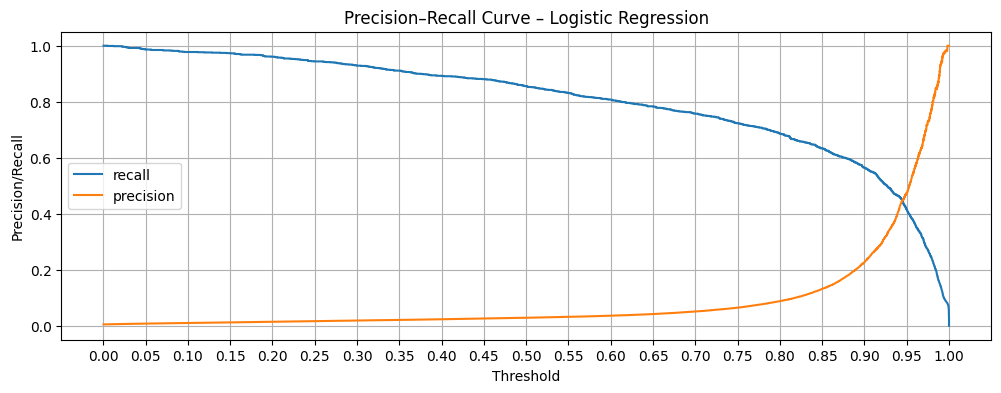

In [37]:
precision, recall, thresholds = precision_recall_curve(y_val, y_proba)

plt.figure(figsize=(12,4))
plt.plot(thresholds, recall[:-1], label="recall")
plt.plot(thresholds, precision[:-1], label="precision")
plt.title("Precision–Recall Curve – Logistic Regression")
plt.xlabel("Threshold")
plt.ylabel("Precision/Recall")
plt.xticks(np.arange(0.0, 1.05, 0.05))
plt.legend()
plt.grid(True)
plt.show()

In [38]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best threshold (F1): {best_threshold:.4f}")
print(f"Best F1 fraud: {best_f1:.4f}")


Best threshold (F1): 0.9441
Best F1 fraud: 0.4484


In [39]:
y_val_pred_opt = (y_proba >= best_threshold).astype(int)

print(classification_report(
    y_val,
    y_val_pred_opt,
    target_names=["legit", "fraud"],
    digits=4
))


              precision    recall  f1-score   support

       legit     0.9969    0.9968    0.9969    223740
       fraud     0.4445    0.4524    0.4484      1249

    accuracy                         0.9938    224989
   macro avg     0.7207    0.7246    0.7227    224989
weighted avg     0.9939    0.9938    0.9938    224989



**Valutazione iniziale con soglia standard (0.5)**

In una prima fase, il modello viene valutato utilizzando la soglia di classificazione standard pari a 0.5, al fine di ottenere un riferimento comparabile con metriche classiche e comprendere il comportamento “grezzo” del classificatore.

L’Average Precision Score (PR-AUC) pari a circa 0.41 indica una buona capacità del modello di ordinare correttamente le transazioni fraudolente rispetto a quelle legittime, in un contesto fortemente sbilanciato. Questa metrica è particolarmente informativa nel contesto della fraud detection, poiché tiene conto dell’intero trade-off precision–recall senza dipendere da una soglia fissa.

Con soglia 0.5, il modello mostra:

- Recall molto elevato sulle frodi (~85%), coerente con l’uso di class_weight="balanced";
- Precisione estremamente bassa (~3%), con un numero elevato di falsi positivi;
- Un’accuratezza complessiva elevata ma poco informativa, data la forte prevalenza della classe legittima.

Questo comportamento è atteso e conferma che la soglia 0.5 non è adeguata in un problema con forte sbilanciamento e costi asimmetrici.
##

**Analisi della curva Precision–Recall e ottimizzazione della soglia (F1)**

Successivamente, viene analizzato l’andamento di precision e recall al variare della soglia di classificazione. La curva evidenzia un forte trade-off:

a soglie basse il modello massimizza il recall intercettando la maggior parte delle frodi, al prezzo di numerosi falsi positivi;

a soglie elevate aumenta la precisione, riducendo i falsi allarmi ma perdendo parte delle frodi.

Come primo esercizio esplorativo, la soglia è stata ottimizzata massimizzando la F1-score sulla classe fraudolenta. La soglia ottimale individuata (~0.94) produce un bilanciamento più equilibrato tra precision e recall:

- Precision fraud ~44%
- Recall fraud ~45%
- F1 fraud ~0.45

Questo risultato dimostra che il modello è in grado di separare efficacemente le transazioni ad alto rischio quando si richiede un maggiore grado di confidenza prima di segnalare una frode.

**Nota:**

L’ottimizzazione della soglia tramite F1-score viene qui utilizzata a scopo diagnostico, per comprendere la capacità discriminativa del modello e il comportamento delle probabilità stimate.

Nelle sezioni successive, la scelta finale della soglia verrà effettuata sulla base di una funzione di costo esplicita, più aderente al contesto di business reale, in cui il costo di una frode non intercettata è significativamente superiore a quello di un falso positivo.

In [45]:
## Ricerca soglia migliore in base alla fascia di costo
for i in range(len(cost_fn)):
  best = best_cost(cost_fn[i], cost_fp, y_val, y_proba)
  best_t = pd.DataFrame([best])
  print(f"Miglior threshold per cost_fn={cost_fn[i]}: {best['threshold']}")
  display(best_t.T)

Miglior threshold per cost_fn=300: 0.8865829145728643


,0
threshold,0.8866
cost,184700.0000
recall,0.5885
precision,0.1942
f1_score,0.2920
pr_auc,0.4147
tn,220690.0000
fp,3050.0000
fn,514.0000
tp,735.0000


Miglior threshold per cost_fn=390: 0.8521105527638191


,0
threshold,0.8521
cost,229880.0000
recall,0.6317
precision,0.1352
f1_score,0.2227
pr_auc,0.4147
tn,218692.0000
fp,5048.0000
fn,460.0000
tp,789.0000


Miglior threshold per cost_fn=530: 0.8422613065326634


,0
threshold,0.8423
cost,292640.0000
recall,0.6445
precision,0.1231
f1_score,0.2068
pr_auc,0.4147
tn,218008.0000
fp,5732.0000
fn,444.0000
tp,805.0000


Miglior threshold per cost_fn=1000: 0.724070351758794


,0
threshold,0.7241
cost,469260.0000
recall,0.7462
precision,0.0577
f1_score,0.1071
pr_auc,0.4147
tn,208514.0000
fp,15226.0000
fn,317.0000
tp,932.0000


In questa fase la soglia di classificazione viene selezionata minimizzando una funzione di costo che penalizza in modo asimmetrico i falsi negativi (frodi non intercettate) e i falsi positivi.
A parità di costo per falso positivo, sono stati valutati diversi scenari di costo associato a una frode non rilevata.

All’aumentare del costo del falso negativo, la soglia ottimale si riduce, favorendo il recall a scapito della precisione.
Questo risultato conferma la possibilità di adattare il comportamento del modello alle diverse priorità di business semplicemente intervenendo sulla soglia decisionale.

In [46]:
'''
  **Nota:** la ricerca su C è stata eseguita offline per ridurre i tempi di esecuzione;
  di seguito vengono riportati i risultati migliori rispetto al costo (scenario base: cost_fn=390, cost_fp=10).

#prima di chiudere con la Logistic Regression, proviamo ad ottimizzare qualche iperparametro
C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0] --> regolarizzazione più o meni forte

results = []

for C in C_values:
    log_reg = LogisticRegression(
        penalty="l2",
        C=C,
        class_weight="balanced",
        solver="lbfgs",
        max_iter=2000,
        n_jobs=-1
    )

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", log_reg)
    ])

    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_val)[:, 1]

    # soglia ottimizzata per costo
    best = best_cost(390, 10, y_val, y_proba)

    results.append({
        "C": C,
        "threshold": best["threshold"],
        "cost": best["cost"],
        "recall": best["recall"],
        "precision": best["precision"]
    })

pd.DataFrame(results).sort_values("cost")
'''

'\n  **Nota:** la ricerca su C è stata eseguita offline per ridurre i tempi di esecuzione;\n  di seguito vengono riportati i risultati migliori rispetto al costo (scenario base: cost_fn=390, cost_fp=10).\n\n#prima di chiudere con la Logistic Regression, proviamo ad ottimizzare qualche iperparametro\nC_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0] --> regolarizzazione più o meni forte\n\nresults = []\n\nfor C in C_values:\n    log_reg = LogisticRegression(\n        penalty="l2",\n        C=C,\n        class_weight="balanced",\n        solver="lbfgs",\n        max_iter=2000,\n        n_jobs=-1\n    )\n\n    pipe = Pipeline([\n        ("preprocess", preprocessor),\n        ("model", log_reg)\n    ])\n\n    pipe.fit(X_train, y_train)\n    y_proba = pipe.predict_proba(X_val)[:, 1]\n\n    # soglia ottimizzata per costo\n    best = best_cost(390, 10, y_val, y_proba)\n\n    results.append({\n        "C": C,\n        "threshold": best["threshold"],\n        "cost": best["cost"],\n        "reca

In [47]:
''' #prova su colab
id  C	    threshold	cost    recall	precision
0	0.0100	0.8521	  230110	0.6317	0.1346 ------> winner per costo
1	0.0500	0.8472	  230830	0.6413	0.1249 ------> recall migliore
2	0.1000	0.8866	  230950	0.5925	0.1857
6	5.0000	0.8866	  231060	0.5925	0.1852
4	1.0000	0.8866	  231090	0.5925	0.1851
3	0.5000	0.8866	  231160	0.5925	0.1848
5	2.0000	0.8817	  231390	0.5973	0.1748

# prova su pc
id  C	    threshold	cost	recall	precision
0	0.0100	0.8423	  229980	0.6461	0.1229 ---->winner per costo e recall
1	0.0500	0.8570 	  230800	0.6277	0.1368
6	5.0000	0.8866	  231090	0.5925	0.1851
4	1.0000	0.8866	  231210	0.5925	0.1845
2	0.1000	0.8866	  231230	0.5917	0.1861
5	2.0000	0.8866	  231260	0.5925	0.1843
3	0.5000	0.8472	  231370	0.6413	0.1239

'''

' #prova su colab\nid  C\t    threshold\tcost    recall\tprecision\n0\t0.0100\t0.8521\t  230110\t0.6317\t0.1346 ------> winner per costo\n1\t0.0500\t0.8472\t  230830\t0.6413\t0.1249 ------> recall migliore\n2\t0.1000\t0.8866\t  230950\t0.5925\t0.1857\n6\t5.0000\t0.8866\t  231060\t0.5925\t0.1852\n4\t1.0000\t0.8866\t  231090\t0.5925\t0.1851\n3\t0.5000\t0.8866\t  231160\t0.5925\t0.1848\n5\t2.0000\t0.8817\t  231390\t0.5973\t0.1748\n\n# prova su pc\nid  C\t    threshold\tcost\trecall\tprecision\n0\t0.0100\t0.8423\t  229980\t0.6461\t0.1229 ---->winner per costo e recall\n1\t0.0500\t0.8570 \t  230800\t0.6277\t0.1368\n6\t5.0000\t0.8866\t  231090\t0.5925\t0.1851\n4\t1.0000\t0.8866\t  231210\t0.5925\t0.1845\n2\t0.1000\t0.8866\t  231230\t0.5917\t0.1861\n5\t2.0000\t0.8866\t  231260\t0.5925\t0.1843\n3\t0.5000\t0.8472\t  231370\t0.6413\t0.1239\n\n'

In [48]:
log_reg = LogisticRegression(
    penalty="l2",
    C=0.01,
    class_weight="balanced",
    solver="lbfgs",
    max_iter=2000,
    n_jobs=-1
)

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", log_reg)
])

pipe.fit(X_train, y_train)
y_proba = pipe.predict_proba(X_val)[:, 1]

best = best_cost(390, 10, y_val, y_proba)
y_pred = (y_proba >= best['threshold']).astype(int)

print("Best threshold (cost):", best["threshold"])
print(classification_report(y_val, y_pred, target_names=["legit", "fraud"], digits=4))

y_lreg = y_proba #checkpoint y_proba threshold Logistic Regression
best_th_lreg = best["threshold"] #checkpoint best threshold Logistic Regression

Best threshold (cost): 0.8521105527638191
              precision    recall  f1-score   support

       legit     0.9979    0.9774    0.9876    223740
       fraud     0.1352    0.6317    0.2227      1249

    accuracy                         0.9755    224989
   macro avg     0.5665    0.8046    0.6051    224989
weighted avg     0.9931    0.9755    0.9833    224989



La Logistic Regression è stata utilizzata come modello baseline interpretabile, con class_weight="balanced" per mitigare il forte sbilanciamento delle classi e privilegiare l’intercettazione delle frodi.
La regolarizzazione L2, con parametro C=0.01, è risultata la scelta più efficace in termini di costo di business, garantendo stabilità in presenza di feature correlate e ad alta dimensionalità.

Il modello è stato inizialmente valutato tramite metriche standard (Precision, Recall, F1-score e AUC-PR), evidenziando il tipico trade-off tra intercettazione delle frodi e numero di falsi positivi. Successivamente, la soglia decisionale è stata ottimizzata tramite una funzione di costo asimmetrica, più aderente al contesto operativo, che penalizza maggiormente le frodi non intercettate rispetto ai falsi allarmi.

L’ottimizzazione della soglia basata sul costo mostra come, in scenari di fraud detection, la scelta della soglia sia spesso più rilevante dell’ottimizzazione del modello stesso, consentendo di adattare il comportamento del sistema a differenti priorità di business a parità di modello predittivo.

È importante sottolineare che i risultati riportati risultano ottimistici, in quanto la soglia ottimale è stata stimata direttamente sulle probabilità predette sul validation set. Questo approccio è stato adottato consapevolmente per analizzare il compromesso costo–prestazioni e calibrare il sistema in un contesto controllato. La soglia così determinata verrà tuttavia mantenuta fissa e utilizzata nella fase di test e inferenza, simulando uno scenario operativo in cui la soglia viene definita su una finestra storica e applicata a nuove transazioni future.

##Random Forest

Per il modello Random Forest è stata adottata una strategia di tuning guidata, evitando grid search esaustive. Gli iperparametri sono stati selezionati sulla base di considerazioni teoriche e testati su un singolo split temporale train-validation. La selezione finale del modello è avvenuta ottimizzando la soglia decisionale rispetto a una funzione di costo di business, privilegiando la riduzione delle frodi non intercettate rispetto alla massimizzazione di metriche standard.

In [50]:
#funzionamento della griglia di combinazioni

param_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_leaf": [50, 100, 300],
    "model__class_weight": ["balanced", "balanced_subsample"],
    "model__max_features": ["sqrt"],
}

keys = list(param_grid.keys())
count = 0
for n in product(*[param_grid[k] for k in keys]):
  print(n) #facciamo una grid search "manuale"
  count += 1
print(count) #48 combinazioni possibili

(200, 8, 50, 'balanced', 'sqrt')
(200, 8, 50, 'balanced_subsample', 'sqrt')
(200, 8, 100, 'balanced', 'sqrt')
(200, 8, 100, 'balanced_subsample', 'sqrt')
(200, 8, 300, 'balanced', 'sqrt')
(200, 8, 300, 'balanced_subsample', 'sqrt')
(200, 12, 50, 'balanced', 'sqrt')
(200, 12, 50, 'balanced_subsample', 'sqrt')
(200, 12, 100, 'balanced', 'sqrt')
(200, 12, 100, 'balanced_subsample', 'sqrt')
(200, 12, 300, 'balanced', 'sqrt')
(200, 12, 300, 'balanced_subsample', 'sqrt')
(200, 16, 50, 'balanced', 'sqrt')
(200, 16, 50, 'balanced_subsample', 'sqrt')
(200, 16, 100, 'balanced', 'sqrt')
(200, 16, 100, 'balanced_subsample', 'sqrt')
(200, 16, 300, 'balanced', 'sqrt')
(200, 16, 300, 'balanced_subsample', 'sqrt')
(200, None, 50, 'balanced', 'sqrt')
(200, None, 50, 'balanced_subsample', 'sqrt')
(200, None, 100, 'balanced', 'sqrt')
(200, None, 100, 'balanced_subsample', 'sqrt')
(200, None, 300, 'balanced', 'sqrt')
(200, None, 300, 'balanced_subsample', 'sqrt')
(500, 8, 50, 'balanced', 'sqrt')
(500, 8, 

In [51]:
cost_fn = 390 #rifissiamo per sicurezza le variabili
cost_fp = 10

In [52]:
'''
# Mini-griglia guidata (sensata per il problema fraud detection)
# =========================
param_grid = {
  "model__n_estimators": [200, 500],
  "model__max_depth": [8, 12, 16, None],
  "model__min_samples_leaf": [50, 100, 300],
  "model__class_weight": ["balanced", "balanced_subsample"],
  "model__max_features": ["sqrt"],
  }

# =========================
# Ricerca "manuale"
# =========================
results = []
count = 0

keys = list(param_grid.keys())
for values in product(*[param_grid[k] for k in keys]):
  params = dict(zip(keys, values))

  rf = RandomForestClassifier(
    n_estimators=params["model__n_estimators"],
    max_depth=params["model__max_depth"],
    min_samples_leaf=params["model__min_samples_leaf"],
    class_weight=params["model__class_weight"],
    max_features=params["model__max_features"],
    n_jobs=-1,
    random_state=42
    )

  rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),   # <<--- stesso preprocessor della Logistic
    ("model", rf)
    ])

  rf_pipe.fit(X_train, y_train)
  y_proba = rf_pipe.predict_proba(X_val)[:, 1]

  pr_auc = average_precision_score(y_val, y_proba)
  best = best_cost(cost_fn, cost_fp, y_val, y_proba)

  results.append({
    "n_estimators": params["model__n_estimators"],
    "max_depth": params["model__max_depth"],
    "min_samples_leaf": params["model__min_samples_leaf"],
    "class_weight": params["model__class_weight"],
    "max_features": params["model__max_features"],
    "pr_auc": pr_auc,
    "best_threshold_cost": best["threshold"],
    "cost": best["cost"],
    "recall": best["recall"],
    "precision": best["precision"],
    "fp": best["fp"],
    "fn": best["fn"],
    "tp": best["tp"],
    "tn": best["tn"]
    })
  count += 1
  print(f"Processata combinazione n. {count} con valori {values}")

res_rf = pd.DataFrame(results).sort_values(["cost", "pr_auc"], ascending=[True, False])
res_rf.head(10)
'''

'\n# Mini-griglia guidata (sensata per il problema fraud detection)\n# =========================\nparam_grid = {\n  "model__n_estimators": [200, 500],\n  "model__max_depth": [8, 12, 16, None],\n  "model__min_samples_leaf": [50, 100, 300],\n  "model__class_weight": ["balanced", "balanced_subsample"],\n  "model__max_features": ["sqrt"],\n  }\n\n# =========================\n# Ricerca "manuale"\n# =========================\nresults = []\ncount = 0\n\nkeys = list(param_grid.keys())\nfor values in product(*[param_grid[k] for k in keys]):\n  params = dict(zip(keys, values))\n\n  rf = RandomForestClassifier(\n    n_estimators=params["model__n_estimators"],\n    max_depth=params["model__max_depth"],\n    min_samples_leaf=params["model__min_samples_leaf"],\n    class_weight=params["model__class_weight"],\n    max_features=params["model__max_features"],\n    n_jobs=-1,\n    random_state=42\n    )\n\n  rf_pipe = Pipeline(steps=[\n    ("preprocess", preprocessor),   # <<--- stesso preprocessor dell

In [53]:
'''
id n_estimators	max_depth	min_samples_leaf	class_weight	max_features	pr_auc	best_threshold_cost	cost	recall	precision	fp	fn	tp	    tn
43	500	         NaN	    50	                balanced_subsample	sqrt	    0.8371	0.3596	            64040	0.9303	0.2785	   3011	87	1162	220729
19	200	         NaN	    50	                balanced_subsample	sqrt	    0.8349	0.3941	            64080	0.9175	0.3240	   2391	103	1146	221349
37	500	        16.0000	    50	                balanced_subsample	sqrt	    0.8426	0.4483	            65130	0.9063	0.3673	   1950	117	1132	221790
12	200	        16.0000	    50	                balanced	        sqrt	    0.8390	0.4384	            65230	0.9087	0.3534	   2077	114	1135	221663
18	200	        NaN	        50	                balanced	        sqrt	    0.8380	0.3793	            65320	0.9223	0.2953	   2749	97	1152	220991
42	500	        NaN	        50	                balanced	        sqrt	    0.8419	0.3793	            65600	0.9215	0.2960	   2738	98	1151	221002
36	500	        16.0000	    50	                balanced	        sqrt	    0.8404	0.3990	            66450	0.9239	0.2819	   2940	95	1154	220800
13	200   	    16.0000	    50	                balanced_subsample	sqrt	    0.8381	0.4237	            66810	0.9143	0.3129	   2508	107	1142	221232
21	200	        NaN	        100	                balanced_subsample	sqrt	    0.8283	0.4778	            67260	0.9135	0.3122	   2514	108	1141	221226
45	500	        NaN	        100	                balanced_subsample	sqrt	    0.8283	0.4680	            67420	0.9167	0.2989	   2686	104	1145	221054
'''

'\nid n_estimators\tmax_depth\tmin_samples_leaf\tclass_weight\tmax_features\tpr_auc\tbest_threshold_cost\tcost\trecall\tprecision\tfp\tfn\ttp\t    tn\n43\t500\t         NaN\t    50\t                balanced_subsample\tsqrt\t    0.8371\t0.3596\t            64040\t0.9303\t0.2785\t   3011\t87\t1162\t220729\n19\t200\t         NaN\t    50\t                balanced_subsample\tsqrt\t    0.8349\t0.3941\t            64080\t0.9175\t0.3240\t   2391\t103\t1146\t221349\n37\t500\t        16.0000\t    50\t                balanced_subsample\tsqrt\t    0.8426\t0.4483\t            65130\t0.9063\t0.3673\t   1950\t117\t1132\t221790\n12\t200\t        16.0000\t    50\t                balanced\t        sqrt\t    0.8390\t0.4384\t            65230\t0.9087\t0.3534\t   2077\t114\t1135\t221663\n18\t200\t        NaN\t        50\t                balanced\t        sqrt\t    0.8380\t0.3793\t            65320\t0.9223\t0.2953\t   2749\t97\t1152\t220991\n42\t500\t        NaN\t        50\t                balanced\t      

In [54]:
best_params = {
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_leaf": 50,
    "class_weight": "balanced_subsample",
    "max_features": "sqrt",
    "pr_auc": 0.8371,
    "best_threshold_cost": 0.3596,
    "cost": 64040,
    "recall": 0.9303,
    "precision": 0.2785,
    "fp": 3011,
    "fn": 87,
    "tp": 1162,
    "tn": 220729
    }

In [61]:
#best_params = res_rf.iloc[0]

best_rf = RandomForestClassifier(
    n_estimators=int(best_params["n_estimators"]),
    max_depth=None if pd.isna(best_params["max_depth"]) else best_params["max_depth"],
    min_samples_leaf=int(best_params["min_samples_leaf"]),
    class_weight=best_params["class_weight"],
    max_features=best_params["max_features"], #qui abbiamo utilizzato sqrt
    n_jobs=-1,
    random_state=42
    )

best_rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", best_rf)
    ])


best_rf_pipe.fit(X_train, y_train)
y_proba = best_rf_pipe.predict_proba(X_val)[:, 1]

best_th_rf = best_params["best_threshold_cost"] #checkpoint best threshold Random Forest
y_pred = (y_proba >= best_th_rf).astype(int)

print("Best threshold (cost):", best_th_rf)
print(classification_report(y_val, y_pred, target_names=["legit", "fraud"], digits=4))

y_rf = y_proba #checkpoint y_proba Random Forest

'''
Best threshold (cost): 0.3596
              precision    recall  f1-score   support

       legit     0.9996    0.9865    0.9930    223740
       fraud     0.2783    0.9303    0.4285      1249

    accuracy                         0.9862    224989
   macro avg     0.6390    0.9584    0.7107    224989
weighted avg     0.9956    0.9862    0.9899    224989
'''

Best threshold (cost): 0.3596
              precision    recall  f1-score   support

       legit     0.9996    0.9865    0.9930    223740
       fraud     0.2783    0.9303    0.4285      1249

    accuracy                         0.9862    224989
   macro avg     0.6390    0.9584    0.7107    224989
weighted avg     0.9956    0.9862    0.9899    224989



'\nBest threshold (cost): 0.3596\n              precision    recall  f1-score   support\n\n       legit     0.9996    0.9865    0.9930    223740\n       fraud     0.2783    0.9303    0.4285      1249\n\n    accuracy                         0.9862    224989\n   macro avg     0.6390    0.9584    0.7107    224989\nweighted avg     0.9956    0.9862    0.9899    224989\n'

In [56]:
#best_params = res_rf.iloc[0] # test con tutte le feature anzichè sqrt

best_rf = RandomForestClassifier(
    n_estimators=int(best_params["n_estimators"]),
    max_depth=None if pd.isna(best_params["max_depth"]) else best_params["max_depth"],
    min_samples_leaf=int(best_params["min_samples_leaf"]),
    class_weight=best_params["class_weight"],
    max_features=None, #qui abbiamo utilizzato tutte le feature
    n_jobs=-1,
    random_state=42
    )

best_rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", best_rf)
    ])
'''
best_rf_pipe.fit(X_train, y_train)
y_proba = best_rf_pipe.predict_proba(X_val)[:, 1]

pr_auc = average_precision_score(y_val, y_proba)
best = best_cost(390, 10, y_val, y_proba)

best_th_rf = best["threshold"] #checkpoint best threshold Random Forest
y_pred = (y_proba >= best_th_rf).astype(int)

print("Cost : ", best['cost'])
print("Best threshold (cost):", best_th_rf)
print(classification_report(y_val, y_pred, target_names=["legit", "fraud"], digits=4))

y_rf = y_proba #checkpoint y_proba Random Forest

Cost : 44190
Best threshold (cost): 0.46798994974874375
              precision    recall  f1-score   support

       legit     0.9997    0.9928    0.9962    223740
       fraud     0.4222    0.9424    0.5831      1249

    accuracy                         0.9925    224989
   macro avg     0.7109    0.9676    0.7897    224989
weighted avg     0.9965    0.9925    0.9939    224989
'''

'\nbest_rf_pipe.fit(X_train, y_train)\ny_proba = best_rf_pipe.predict_proba(X_val)[:, 1]\n\npr_auc = average_precision_score(y_val, y_proba)\nbest = best_cost(390, 10, y_val, y_proba)\n\nbest_th_rf = best["threshold"] #checkpoint best threshold Random Forest\ny_pred = (y_proba >= best_th_rf).astype(int)\n\nprint("Cost : ", best[\'cost\'])\nprint("Best threshold (cost):", best_th_rf)\nprint(classification_report(y_val, y_pred, target_names=["legit", "fraud"], digits=4))\n\ny_rf = y_proba #checkpoint y_proba Random Forest\n\nCost : 44190\nBest threshold (cost): 0.46798994974874375\n              precision    recall  f1-score   support\n\n       legit     0.9997    0.9928    0.9962    223740\n       fraud     0.4222    0.9424    0.5831      1249\n\n    accuracy                         0.9925    224989\n   macro avg     0.7109    0.9676    0.7897    224989\nweighted avg     0.9965    0.9925    0.9939    224989\n'

In [62]:
cost_fn=[300,390, 530, 1000] #Calcolo miglior soglia per fascia di costo come fatto in precedenza
cost_fp=10

for i in range(len(cost_fn)):
  best = best_cost(cost_fn[i], cost_fp, y_val, y_proba)
  best_t = pd.DataFrame([best])
  print(f"Miglior threshold per cost_fn={cost_fn[i]}: {best['threshold']}")
  display(best_t.T)

Miglior threshold per cost_fn=300: 0.3891959798994975


,0
threshold,0.3892
cost,55790.0000
recall,0.9159
precision,0.3202
f1_score,0.4745
pr_auc,0.8371
tn,221311.0000
fp,2429.0000
fn,105.0000
tp,1144.0000


Miglior threshold per cost_fn=390: 0.3596482412060302


,0
threshold,0.3596
cost,64040.0000
recall,0.9303
precision,0.2785
f1_score,0.4286
pr_auc,0.8371
tn,220729.0000
fp,3011.0000
fn,87.0000
tp,1162.0000


Miglior threshold per cost_fn=530: 0.33994974874371864


,0
threshold,0.3399
cost,75790.0000
recall,0.9384
precision,0.2510
f1_score,0.3960
pr_auc,0.8371
tn,220242.0000
fp,3498.0000
fn,77.0000
tp,1172.0000


Miglior threshold per cost_fn=1000: 0.3054773869346734


,0
threshold,0.3055
cost,110970.0000
recall,0.9480
precision,0.2048
f1_score,0.3368
pr_auc,0.8371
tn,219143.0000
fp,4597.0000
fn,65.0000
tp,1184.0000


Dopo aver validato la Logistic Regression come baseline interpretabile, è stato addestrato un modello Random Forest per catturare relazioni non lineari e interazioni complesse tra le feature. Lo sbilanciamento delle classi è stato gestito tramite l’uso di class_weight, coerentemente con il contesto di fraud detection.

Il tuning degli iperparametri è stato condotto tramite una ricerca guidata, evitando grid search esaustive. I parametri principali (numero di alberi, profondità massima e numero minimo di osservazioni per foglia) sono stati selezionati sulla base di considerazioni teoriche e validati su un singolo split temporale train–validation. La selezione finale del modello è avvenuta minimizzando una funzione di costo di business, piuttosto che ottimizzando esclusivamente metriche standard.

Rispetto alla Logistic Regression, la Random Forest mostra un netto miglioramento del recall sulle frodi, intercettando oltre il 90% delle transazioni fraudolente negli scenari di costo considerati. Questo incremento avviene a fronte di un aumento controllato dei falsi positivi, rendendo il modello particolarmente adatto a contesti in cui il costo di una frode non intercettata è significativamente superiore al costo operativo di un falso allarme.

Sono state confrontate due configurazioni del modello, variando il parametro max_features ("sqrt" e None). L’utilizzo di tutte le feature disponibili (max_features=None) ha portato a un miglioramento significativo delle prestazioni sulla classe fraudolenta, in particolare in termini di precision a quasi parità di recall, con una conseguente riduzione del costo di business complessivo. Il trade-off osservato è stato un aumento del tempo di addestramento, ritenuto accettabile nel contesto di training offline.

È importante sottolineare che le prestazioni riportate rappresentano una stima ottimistica, in quanto la soglia decisionale è stata ottimizzata direttamente sulle probabilità predette sul validation set. Questo approccio è stato adottato consapevolmente per studiare il comportamento del modello e il trade-off costo–beneficio in fase di validazione.

##XGBoost

In [63]:
# 1) Preprocessing identico (stesso preprocessor già usato)

proc_xgb = ColumnTransformer(
  transformers=[
    ("num", StandardScaler(), num_scaled_features),
    ("passthrough", "passthrough", num_not_scaled)
    ], remainder="drop") #non considerare eventuali feature future non comprese in quelle passate

X_train_t = proc_xgb.fit_transform(X_train)
X_val_t   = proc_xgb.transform(X_val)

In [ ]:
# 2) scale_pos_weight = neg/pos (su train)
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / max(n_pos, 1)

xgb = XGBClassifier(
    n_estimators=5000,            # alto, poi decide early stopping
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight, # aumenta il peso degli esempi positivi, così da gestire lo sbilanciamento
    tree_method="hist",
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=False
)

# Probabilità su validation
y_proba = xgb.predict_proba(X_val_t)[:, 1]
pr_auc = average_precision_score(y_val, y_proba)
print("PR-AUC:", pr_auc)

# Soglia ottima per costo
best = best_cost(390, 10, y_val, y_proba)

y_pred = (y_proba >= best['threshold']).astype(int)

print("Best threshold (cost):", best['threshold'])
print(classification_report(y_val, y_pred, target_names=["legit", "fraud"], digits=4))

PR-AUC: 0.9686328907654508
Best threshold (cost): 0.16266331658291458
              precision    recall  f1-score   support

       legit     0.9999    0.9969    0.9984    223740
       fraud     0.6388    0.9744    0.7717      1249

    accuracy                         0.9968    224989
   macro avg     0.8194    0.9857    0.8851    224989
weighted avg     0.9979    0.9968    0.9971    224989



In [ ]:
best['cost'] #Costo calcolato

np.int64(19360)

In [ ]:
#funzionamento della griglia di combinazioni

param_grid = {
    "max_depth": [4, 6, 8],
    "min_child_weight": [30, 50, 100],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 5.0],
    "learning_rate": [0.05],   # tienilo fisso per stabilità
}

keys = list(param_grid.keys())
count = 0
for n in product(*[param_grid[k] for k in keys]):
  print(n)
  count += 1
print(count) #72 combinazioni possibili

(4, 30, 0.8, 0.8, 1.0, 0.05)
(4, 30, 0.8, 0.8, 5.0, 0.05)
(4, 30, 0.8, 1.0, 1.0, 0.05)
(4, 30, 0.8, 1.0, 5.0, 0.05)
(4, 30, 1.0, 0.8, 1.0, 0.05)
(4, 30, 1.0, 0.8, 5.0, 0.05)
(4, 30, 1.0, 1.0, 1.0, 0.05)
(4, 30, 1.0, 1.0, 5.0, 0.05)
(4, 50, 0.8, 0.8, 1.0, 0.05)
(4, 50, 0.8, 0.8, 5.0, 0.05)
(4, 50, 0.8, 1.0, 1.0, 0.05)
(4, 50, 0.8, 1.0, 5.0, 0.05)
(4, 50, 1.0, 0.8, 1.0, 0.05)
(4, 50, 1.0, 0.8, 5.0, 0.05)
(4, 50, 1.0, 1.0, 1.0, 0.05)
(4, 50, 1.0, 1.0, 5.0, 0.05)
(4, 100, 0.8, 0.8, 1.0, 0.05)
(4, 100, 0.8, 0.8, 5.0, 0.05)
(4, 100, 0.8, 1.0, 1.0, 0.05)
(4, 100, 0.8, 1.0, 5.0, 0.05)
(4, 100, 1.0, 0.8, 1.0, 0.05)
(4, 100, 1.0, 0.8, 5.0, 0.05)
(4, 100, 1.0, 1.0, 1.0, 0.05)
(4, 100, 1.0, 1.0, 5.0, 0.05)
(6, 30, 0.8, 0.8, 1.0, 0.05)
(6, 30, 0.8, 0.8, 5.0, 0.05)
(6, 30, 0.8, 1.0, 1.0, 0.05)
(6, 30, 0.8, 1.0, 5.0, 0.05)
(6, 30, 1.0, 0.8, 1.0, 0.05)
(6, 30, 1.0, 0.8, 5.0, 0.05)
(6, 30, 1.0, 1.0, 1.0, 0.05)
(6, 30, 1.0, 1.0, 5.0, 0.05)
(6, 50, 0.8, 0.8, 1.0, 0.05)
(6, 50, 0.8, 0.8, 5.0, 0.05)
(6, 50

In [ ]:
##funzionamento dictionary unpacking

a = {
    "max_depth": 4,
    "min_child_weight": 30,
    "subsample": 1,
    "colsample_bytree": 1,
    "reg_lambda": 5,
    "learning_rate": 0.5
}

b ={**a}
b

{'max_depth': 4,
 'min_child_weight': 30,
 'subsample': 1,
 'colsample_bytree': 1,
 'reg_lambda': 5,
 'learning_rate': 0.5}

In [ ]:
# 1) Mini-griglia guidata (pochi parametri, ma coerenti con il problema)

param_grid = {
    "max_depth": [4, 6, 8],
    "min_child_weight": [30, 50, 100],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 5.0],
    "learning_rate": [0.05], #valutare se aggiungere
}

# 2) Ricerca manuale

results = []
keys = list(param_grid.keys())
count = 0

for values in product(*[param_grid[k] for k in keys]):
    p = dict(zip(keys, values))

    xgb = XGBClassifier(
        n_estimators=5000,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=100,

        # parametri da griglia
        max_depth=p["max_depth"],
        min_child_weight=p["min_child_weight"],
        subsample=p["subsample"],
        colsample_bytree=p["colsample_bytree"],
        reg_lambda=p["reg_lambda"],
        learning_rate=p["learning_rate"]
    )

    xgb.fit(
        X_train_t, y_train,
        eval_set=[(X_val_t, y_val)],
        verbose=False
    )

    y_proba = xgb.predict_proba(X_val_t)[:, 1]
    pr_auc = average_precision_score(y_val, y_proba)

    best = best_cost(390, 10, y_val, y_proba)

    results.append({
        **p,
        "best_iteration": getattr(xgb, "best_iteration", None),
        "pr_auc": pr_auc,
        "best_threshold_cost": best["threshold"],
        "cost": best["cost"],
        "recall": best["recall"],
        "precision": best["precision"],
        "fp": best["fp"],
        "fn": best["fn"],
        "tp": best["tp"],
        "tn": best["tn"]
    })

    count += 1
    print(f"Processata combinazione n. {count} con valori {values}")

res_xgb = pd.DataFrame(results).sort_values(["cost", "pr_auc"], ascending=[True, False])
res_xgb.head(10)


Processata combinazione n. 1 con valori (4, 30, 0.8, 0.8, 1.0, 0.05)
Processata combinazione n. 2 con valori (4, 30, 0.8, 0.8, 5.0, 0.05)
Processata combinazione n. 3 con valori (4, 30, 0.8, 1.0, 1.0, 0.05)
Processata combinazione n. 4 con valori (4, 30, 0.8, 1.0, 5.0, 0.05)
Processata combinazione n. 5 con valori (4, 30, 1.0, 0.8, 1.0, 0.05)
Processata combinazione n. 6 con valori (4, 30, 1.0, 0.8, 5.0, 0.05)
Processata combinazione n. 7 con valori (4, 30, 1.0, 1.0, 1.0, 0.05)
Processata combinazione n. 8 con valori (4, 30, 1.0, 1.0, 5.0, 0.05)
Processata combinazione n. 9 con valori (4, 50, 0.8, 0.8, 1.0, 0.05)
Processata combinazione n. 10 con valori (4, 50, 0.8, 0.8, 5.0, 0.05)
Processata combinazione n. 11 con valori (4, 50, 0.8, 1.0, 1.0, 0.05)
Processata combinazione n. 12 con valori (4, 50, 0.8, 1.0, 5.0, 0.05)
Processata combinazione n. 13 con valori (4, 50, 1.0, 0.8, 1.0, 0.05)
Processata combinazione n. 14 con valori (4, 50, 1.0, 0.8, 5.0, 0.05)
Processata combinazione n. 15

,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,learning_rate,best_iteration,pr_auc,best_threshold_cost,cost,recall,precision,fp,fn,tp,tn
69,8,100,1.0000,0.8000,5.0000,0.0500,829,0.9746,0.2316,15430,0.9816,0.6549,646,23,1226,223094
55,8,30,1.0000,1.0000,5.0000,0.0500,704,0.9750,0.1282,16030,0.9800,0.6609,628,25,1224,223112
60,8,50,1.0000,0.8000,1.0000,0.0500,743,0.9749,0.1922,16160,0.9776,0.6997,524,28,1221,223216
71,8,100,1.0000,1.0000,5.0000,0.0500,685,0.9730,0.3449,16190,0.9768,0.7143,488,29,1220,223252
29,6,30,1.0000,0.8000,5.0000,0.0500,1945,0.9749,0.0395,16300,0.9832,0.6023,811,21,1228,222929
45,6,100,1.0000,0.8000,5.0000,0.0500,1323,0.9724,0.3301,16320,0.9752,0.7422,423,31,1218,223317
38,6,50,1.0000,1.0000,1.0000,0.0500,1176,0.9734,0.1824,16350,0.9768,0.7077,504,29,1220,223236
66,8,100,0.8000,1.0000,1.0000,0.0500,872,0.9711,0.2858,16440,0.9776,0.6887,552,28,1221,223188
47,6,100,1.0000,1.0000,5.0000,0.0500,1208,0.9715,0.1922,16500,0.9808,0.6318,714,24,1225,223026
67,8,100,0.8000,1.0000,5.0000,0.0500,906,0.9713,0.2267,16600,0.9800,0.6412,685,25,1224,223055


In [ ]:
'''
id max_depth	min_child_weight	subsample	colsample_bytree	reg_lambda	learning_rate	best_iteration	pr_auc	best_threshold_cost	cost	recall	precision	fp	fn	tp	tn
69	8	100	1.0000	0.8000	5.0000	0.0500	829	0.9746	0.2316	15430	0.9816	0.6549	646	23	1226	223094
55	8	30	1.0000	1.0000	5.0000	0.0500	704	0.9750	0.1282	16030	0.9800	0.6609	628	25	1224	223112
60	8	50	1.0000	0.8000	1.0000	0.0500	743	0.9749	0.1922	16160	0.9776	0.6997	524	28	1221	223216
71	8	100	1.0000	1.0000	5.0000	0.0500	685	0.9730	0.3449	16190	0.9768	0.7143	488	29	1220	223252
29	6	30	1.0000	0.8000	5.0000	0.0500	1945	0.9749	0.0395	16300	0.9832	0.6023	811	21	1228	222929
45	6	100	1.0000	0.8000	5.0000	0.0500	1323	0.9724	0.3301	16320	0.9752	0.7422	423	31	1218	223317
38	6	50	1.0000	1.0000	1.0000	0.0500	1176	0.9734	0.1824	16350	0.9768	0.7077	504	29	1220	223236
66	8	100	0.8000	1.0000	1.0000	0.0500	872	0.9711	0.2858	16440	0.9776	0.6887	552	28	1221	223188
47	6	100	1.0000	1.0000	5.0000	0.0500	1208	0.9715	0.1922	16500	0.9808	0.6318	714	24	1225	223026
67	8	100	0.8000	1.0000	5.0000	0.0500	906	0.9713	0.2267	16600	0.9800	0.6412	685	25	1224	223055
'''

'\nid max_depth\tmin_child_weight\tsubsample\tcolsample_bytree\treg_lambda\tlearning_rate\tbest_iteration\tpr_auc\tbest_threshold_cost\tcost\trecall\tprecision\tfp\tfn\ttp\ttn\n69\t8\t100\t1.0000\t0.8000\t5.0000\t0.0500\t829\t0.9746\t0.2316\t15430\t0.9816\t0.6549\t646\t23\t1226\t223094\n55\t8\t30\t1.0000\t1.0000\t5.0000\t0.0500\t704\t0.9750\t0.1282\t16030\t0.9800\t0.6609\t628\t25\t1224\t223112\n60\t8\t50\t1.0000\t0.8000\t1.0000\t0.0500\t743\t0.9749\t0.1922\t16160\t0.9776\t0.6997\t524\t28\t1221\t223216\n71\t8\t100\t1.0000\t1.0000\t5.0000\t0.0500\t685\t0.9730\t0.3449\t16190\t0.9768\t0.7143\t488\t29\t1220\t223252\n29\t6\t30\t1.0000\t0.8000\t5.0000\t0.0500\t1945\t0.9749\t0.0395\t16300\t0.9832\t0.6023\t811\t21\t1228\t222929\n45\t6\t100\t1.0000\t0.8000\t5.0000\t0.0500\t1323\t0.9724\t0.3301\t16320\t0.9752\t0.7422\t423\t31\t1218\t223317\n38\t6\t50\t1.0000\t1.0000\t1.0000\t0.0500\t1176\t0.9734\t0.1824\t16350\t0.9768\t0.7077\t504\t29\t1220\t223236\n66\t8\t100\t0.8000\t1.0000\t1.0000\t0.0500\t872

È stato addestrato un modello XGBoost con gestione esplicita dello sbilanciamento delle classi tramite il parametro scale_pos_weight, calcolato come rapporto tra esempi negativi e positivi nel training set. Questa scelta consente di penalizzare maggiormente gli errori sulla classe fraudolenta, coerentemente con il contesto applicativo.

Il preprocessing è stato mantenuto identico a quello utilizzato per Logistic Regression e Random Forest, garantendo un confronto equo tra i modelli. L’addestramento è stato effettuato con un numero elevato di alberi (n_estimators=5000) e early stopping basato sulla PR-AUC calcolata sul validation set, così da prevenire overfitting e selezionare automaticamente il numero ottimale di iterazioni.

È stata eseguita una mini-grid search manuale su un insieme ristretto ma significativo di iperparametri chiave, evitando una ricerca esaustiva e privilegiando configurazioni coerenti con il problema di fraud detection.

La selezione del modello non è stata guidata esclusivamente da metriche standard, ma dalla minimizzazione di una funzione di costo di business, che penalizza maggiormente i falsi negativi rispetto ai falsi positivi. La soglia decisionale è stata quindi ottimizzata a posteriori sulle probabilità predette, anziché fissata arbitrariamente a 0.5.

Rispetto a Logistic Regression e Random Forest, XGBoost mostra un ulteriore e marcato miglioramento delle prestazioni, con PR-AUC molto elevata e un recall sulle frodi superiore al 97%, mantenendo al contempo un livello di precision significativamente più alto rispetto agli altri modelli. Questo si traduce in una riduzione drastica del costo di business atteso, rendendo XGBoost il modello più efficace tra quelli analizzati nel contesto considerato.

I risultati riportati sulla validation rappresentano una stima ottimistica per i motivi detti in precedenza.
Mentre il dataset di test verrà utilizzato una sola volta, senza ulteriori ottimizzazioni, per la valutazione finale e il confronto imparziale delle performance dei modelli selezionati, simulando uno scenario realistico di deployment.

In [ ]:
## Addestramento e salvataggio modelli finali (Utilizzo direttamnente i dataset trasformati con preprocessor (X_train_t, X_val_t))

def th_for_cost_level_dict(y_val, y_proba):
    cost_fn=[300,390, 530, 1000]
    cost_fp=10
    cost_n =['Conservative', 'Baseline', 'Medium-high', 'High']
    th_dir = {}
    cost_dir = {}
    recall_dir = {}
    precision_dir = {}
    f1_score_dir = {}
    pr_auc_dir = {}


    for lab, fn_cost in zip(cost_n, cost_fn):
        best = best_cost(fn_cost, cost_fp, y_val, y_proba)
        th_dir[lab] = best['threshold']
        cost_dir[lab] = best['cost']
        recall_dir[lab] = best['recall']
        precision_dir[lab] = best['precision']
        f1_score_dir[lab] = best['f1_score']
        pr_auc_dir[lab] = best['pr_auc']

    return th_dir, cost_dir, recall_dir, precision_dir, f1_score_dir, pr_auc_dir

def save_model_ths(model, ths, costs, recalls, precisions, f1_scores, pr_aucs,  name :str, version :str):
    joblib.dump(
        {
            "model": model,
            "thresholds": ths,
            "costs" : costs,
            "recalls" : recalls,
            "precisions" : precisions,
            "f1_scores" : f1_scores,
            "pr_aucs" : pr_aucs,
        },
        f"fraud_{name}_{version}.joblib"
    )

def load_model_ths(path :str):
    loaded = joblib.load(path)

    new_model = loaded["model"]
    new_ths = loaded["thresholds"]
    new_costs = loaded["costs"]
    new_recalls = loaded["recalls"]
    new_precisions = loaded["precisions"]
    new_f1_scores = loaded["f1_scores"]
    new_pr_aucs = loaded["pr_aucs"]

    return new_model, new_ths, new_costs, new_recalls, new_precisions, new_f1_scores, new_pr_aucs

def load_model_ths_old(path :str):
    loaded = joblib.load(path)

    new_model = loaded["model"]
    new_ths = loaded["thresholds"]
    new_costs = loaded["costs"]
    new_recalls = loaded["recalls"]
    new_precisions = loaded["precisions"]

    return new_model, new_ths, new_costs, new_recalls, new_precisions

In [ ]:
# Logistic Regression Final

lreg_model = LogisticRegression(
    penalty="l2",
    C=0.01,
    class_weight="balanced",
    solver="lbfgs",
    max_iter=2000,
    n_jobs=-1
)

lreg_model.fit(X_train_t, y_train)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=2000, n_jobs=-1)

In [ ]:
y_proba = lreg_model.predict_proba(X_val_t)[:, 1]
y_pred_new = (y_proba >= new_th_logreg).astype(int) # th checkpoint precedente
print(classification_report(y_val, y_pred_new, target_names=["legit", "fraud"], digits=4)) #giusto per verifica dei valori precedenti

              precision    recall  f1-score   support

       legit     0.9980    0.9743    0.9860    223740
       fraud     0.1229    0.6461    0.2065      1249

    accuracy                         0.9724    224989
   macro avg     0.5604    0.8102    0.5962    224989
weighted avg     0.9931    0.9724    0.9816    224989



In [ ]:
lreg_ths, lreg_cost, lreg_recall, lreg_precision, lreg_f1_score, lreg_pr_auc = th_for_cost_level_dict(y_val, y_proba)
lreg_ths

{'Conservative': np.float64(0.8865829145728643),
 'Baseline': np.float64(0.8422613065326634),
 'Medium-high': np.float64(0.8422613065326634),
 'High': np.float64(0.724070351758794)}

In [ ]:
save_model_ths(lreg_model, lreg_ths, lreg_cost, lreg_recall, lreg_precision, lreg_f1_score, lreg_pr_auc, "Log_Reg", "v2")

In [ ]:
new_mod_lr, ths_lr, costs_lr, recalls_lr, precisions_lr, f1_scores_lr, pr_aucs_lr = load_model_ths("fraud_Log_Reg_v2.joblib")
ths_lr #verifica

{'Conservative': np.float64(0.8865829145728643),
 'Baseline': np.float64(0.8422613065326634),
 'Medium-high': np.float64(0.8422613065326634),
 'High': np.float64(0.724070351758794)}

In [ ]:
y_proba = new_mod_lr.predict_proba(X_val_t)[:, 1]
y_p_new = (y_proba >= ths_lr["Baseline"]).astype(int)
print(classification_report(y_val, y_p_new, target_names=["legit", "fraud"], digits=4)) #giusto per verifica dei valori precedenti

              precision    recall  f1-score   support

       legit     0.9980    0.9743    0.9860    223740
       fraud     0.1229    0.6461    0.2065      1249

    accuracy                         0.9724    224989
   macro avg     0.5604    0.8102    0.5962    224989
weighted avg     0.9931    0.9724    0.9816    224989



In [ ]:
# Random Forest Final
rf_model = RandomForestClassifier(
    n_estimators= 500,
    max_depth= None,
    min_samples_leaf= 50,
    class_weight= "balanced_subsample",
    max_features= None, #qui abbiamo utilizzato tutte le feature
    n_jobs=-1,
    random_state=42
    )

rf_model.fit(X_train_t, y_train)


In [ ]:
y_proba = rf_model.predict_proba(X_val_t)[:, 1]

In [ ]:
rf_ths, rf_cost, rf_recall, rf_precision, rf_f1_score, rf_pr_auc = th_for_cost_level_dict(y_val, y_proba)
rf_ths

{'Conservative': np.float64(0.47783919597989954),
 'Baseline': np.float64(0.46798994974874375),
 'Medium-high': np.float64(0.32025125628140705),
 'High': np.float64(0.32025125628140705)}

In [ ]:
save_model_ths(rf_model, rf_ths, rf_cost, rf_recall, rf_precision, rf_f1_score, rf_pr_auc, "Rand_For", "v2")

In [ ]:
new_rf_model, ths_rf, costs_rf, recalls_rf, precisions_rf, f1_scores_rf, pr_aucs_rf = load_model_ths("fraud_Rand_For_v2.joblib")

In [ ]:
ths_rf

{'Conservative': np.float64(0.47783919597989954),
 'Baseline': np.float64(0.46798994974874375),
 'Medium-high': np.float64(0.32025125628140705),
 'High': np.float64(0.32025125628140705)}

In [ ]:
# XGB Final

#scale_pos_weight = neg/pos (su train)
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / max(n_pos, 1)

xgb = XGBClassifier(
    n_estimators=5000,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=100,

    # parametri da griglia
    max_depth= 8,
    min_child_weight= 100,
    subsample= 1.0,
    colsample_bytree= 0.8,
    reg_lambda= 5.0,
    learning_rate= 0.05
)

xgb.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=False
)



In [ ]:
y_proba = xgb.predict_proba(X_val_t)[:, 1]

In [ ]:
xgb_ths, xgb_cost, xgb_recall, xgb_precision, xgb_f1_score, xgb_pr_auc = th_for_cost_level_dict(y_val, y_proba)
xgb_ths

{'Conservative': np.float64(0.23160804020100503),
 'Baseline': np.float64(0.23160804020100503),
 'Medium-high': np.float64(0.21190954773869347),
 'High': np.float64(0.21190954773869347)}

In [ ]:
save_model_ths(xgb, xgb_ths, xgb_cost, xgb_recall, xgb_precision, xgb_f1_score, xgb_pr_auc, "XGB", "v2")

In [ ]:
new_mod_xgb, ths_xgb, costs_xgb, recalls_xgb, precisions_xgb, f1_scores_xgb, pr_aucs_xgb = load_model_ths("fraud_XGB_v2.joblib")

In [ ]:
ths_xgb

{'Conservative': np.float64(0.23160804020100503),
 'Baseline': np.float64(0.23160804020100503),
 'Medium-high': np.float64(0.21190954773869347),
 'High': np.float64(0.21190954773869347)}

In [ ]:
print(new_mod_xgb, ths_xgb, costs_xgb, recalls_xgb, precisions_xgb) #per check

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=100, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=5000,
              n_jobs=-1, num_parallel_tree=None, ...) {'Conservative': np.float64(0.23160804020100503), 'Baseline': np.float64(0.23160804020100503), 'Medium-high': np.float64(0.21190954773869347), 'High': np.float64(0.21190954773869347)} {'Conservative': np.int64(13360), 'Baseline': np.int64(15430

In questa sezione vengono addestrati i modelli finali e salvati insieme alle soglie ottimali calcolate su diversi scenari di costo (Conservative, Baseline, Medium-high, High).
In fase di test e inferenza, la decisione fraud/legit verrà ottenuta confrontando la probabilità stimata con la soglia corrispondente allo scenario di business scelto.

In [ ]:
#Salviamo anche il Preprocessor addestrato su dataset di train

print(len(num_scaled_features))
print(len(num_not_scaled))

preprocessor_final = ColumnTransformer(
  transformers=[
    ("num", StandardScaler(), num_scaled_features),
    ("passthrough", "passthrough", num_not_scaled)
    ], remainder="drop") #non considerare eventuali feature future non comprese in quelle passate

preprocessor_final.fit(X_train)

22
72


In [ ]:
joblib.dump(
    {
        "preprocessor": preprocessor_final,
        "num_scaled_features": num_scaled_features,
        "num_not_scaled": num_not_scaled
    },
    "preprocessor_v1.joblib"
)

['preprocessor_v1.joblib']

In [ ]:
proc_loader = joblib.load("preprocessor_v1.joblib") #check di caricamento

proc = proc_loader["preprocessor"]
num_scaled_features = proc_loader["num_scaled_features"]
num_not_scaled = proc_loader["num_not_scaled"]

In [ ]:
print(num_scaled_features, len(num_scaled_features))
print(num_not_scaled, len(num_not_scaled))
proc

['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'log_amt', 'log_city_pop', 'cust_merch_km', 'age', 'cust_txn_count_so_far', 'cust_fraud_count_so_far', 'cust_fraud_rate_so_far_smoothed', 'cust_delta_prev_sec', 'merchant_risk_score_smoothed', 'merchant_txn_count_so_far', 'job_risk_score_smoothed', 'job_txn_count_so_far', 'zip_risk_score_smoothed', 'zip_txn_count_so_far', 'city_risk_score_smoothed', 'city_txn_count_so_far'] 22
['hour', 'dayofweek', 'month', 'is_weekend', 'is_night', 'new_merchant_for_customer', 'gender_M', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'state_AK', 'state_AL', 'state_AR', 'state_AZ', 'state_CA', 'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL', 's

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
                                  'month_sin', 'month_cos', 'log_amt',
                                  'log_city_pop', 'cust_merch_km', 'age',
                                  'cust_txn_count_so_far',
                                  'cust_fraud_count_so_far',
                                  'cust_fraud_rate_so_far_smoothed',
                                  'cust_delta_prev_sec',
                                  'merchant_risk_score_smoothed',
                                  'merchant_txn_count_so_far',
                                  'job_risk_score...
                                  'category_gas_transport',
                                  'category_grocery_net',
                                  'category_grocery_pos',
                                  'category_health_fitness', 'category_home',
                                  'category_kids_pets', 'category_misc_net',
                                  'category_misc_pos', 'category_personal_care',
                                  'category_shopping_net',
                                  'category_shopping_pos', 'category_travel',
                                  'state_AK', 'state_AL', 'state_AR',
                                  'state_AZ', 'state_CA', 'state_CO',
                                  'state_CT', 'state_DC', 'state_DE', ...])])

Il preprocessor addestrato sul dataset di training viene salvato insieme alla configurazione delle feature scalate e non scalate.
In questo modo, l’intera pipeline di preprocessing rimane coerente tra fase di validazione, test finale e potenziale utilizzo in produzione.

In [ ]:
## Ultimo test, come si comporterebbe un modello addestrato senza le feature avanzate aggiunte in sede di feature engineering?
#Lasciando solo le trasformazioni base delle feature già esistenti
feature_base = [
    "hour","dayofweek","month","log_amt","log_city_pop",
    "cust_merch_km","age", #trasformazioni base
    "category_entertainment","category_food_dining","category_gas_transport","category_grocery_net",
    "category_grocery_pos","category_health_fitness","category_home","category_kids_pets","category_misc_net",
    "category_misc_pos","category_personal_care","category_shopping_net","category_shopping_pos","category_travel","state_AK",
    "state_AL","state_AR","state_AZ","state_CA","state_CO","state_CT","state_DC","state_DE","state_FL","state_GA","state_HI","state_IA",
    "state_ID","state_IL","state_IN","state_KS","state_KY","state_LA","state_MA","state_MD","state_ME","state_MI","state_MN","state_MO",
    "state_MS","state_MT","state_NC","state_ND","state_NE","state_NH","state_NJ","state_NM","state_NV","state_NY","state_OH","state_OK",
    "state_OR","state_PA","state_RI","state_SC","state_SD","state_TN","state_TX","state_UT","state_VA","state_VT","state_WA","state_WI",
    "state_WV","state_WY","gender_M"
]
#X_val.info()
X_train_base = X_train[feature_base]
X_val_base = X_val[feature_base]
X_train_base.head()

,hour,dayofweek,month,log_amt,log_city_pop,cust_merch_km,age,category_entertainment,category_food_dining,category_gas_transport,...,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,gender_M
0,0,1,1,1.7867,8.1594,78.5976,30.8145,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,1,4.6843,5.0106,30.2122,40.5311,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,1,1,5.3987,8.3321,108.2061,56.9500,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,1,1,3.8286,7.5704,95.6732,51.9699,0,0,1,...,0,0,0,0,0,0,0,0,0,1
4,0,1,1,3.7603,4.6052,77.5567,32.7639,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [ ]:
# n.22 feature da scalare
num_scaled_features_base = [
  "log_amt","log_city_pop","cust_merch_km","age",
  ]

# n.72 feature da non scalare
num_not_scaled_base = ["hour","dayofweek","month","gender_M"]

num_not_scaled_base += [c for c in X_val_base.columns if c.startswith("category_")]
num_not_scaled_base += [c for c in X_val_base.columns if c.startswith("state_")]

print(len(num_scaled_features_base))
print(len(num_not_scaled_base))

4
69


In [ ]:
#proc --> processore standard già addestrato

preprocessor_base = ColumnTransformer(
  transformers=[
    ("num", StandardScaler(), num_scaled_features_base),
    ("passthrough", "passthrough", num_not_scaled_base)
    ], remainder="drop") #non considerare eventuali feature future non comprese in quelle passate

X_train_base_proc = preprocessor_base.fit_transform(X_train_base)
X_val_base_proc = preprocessor_base.transform(X_val_base)

X_val_base_proc.shape

(224989, 73)

In [ ]:
#Addestramento miglior modello XGB

# XGB Final

#scale_pos_weight = neg/pos (su train)
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / max(n_pos, 1)

xgb_base = XGBClassifier(
    n_estimators=5000,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=100,

    # parametri da griglia
    max_depth= 8,
    min_child_weight= 100,
    subsample= 1.0,
    colsample_bytree= 0.8,
    reg_lambda= 5.0,
    learning_rate= 0.05
)

xgb_base.fit(
    X_train_base_proc, y_train,
    eval_set=[(X_val_base_proc, y_val)],
    verbose=False
)




XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=100, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=5000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
y_proba_base = xgb_base.predict_proba(X_val_base_proc)[:, 1]
xgb_ths_base, xgb_cost_base, xgb_recall_base, xgb_precision_base, xgb_f1_score_base, xgb_pr_auc_base = th_for_cost_level_dict(y_val, y_proba_base)
xgb_ths_base

{'Conservative': np.float64(0.6551256281407035),
 'Baseline': np.float64(0.5861809045226131),
 'Medium-high': np.float64(0.5763316582914573),
 'High': np.float64(0.37442211055276386)}

In [ ]:
#Caricamento risultati con Dataset completo
xgb_model, xgb_ths_val, xgb_costs_val, xgb_recalls_val, xgb_precisions_val, xgb_f1_scores_val, xgb_pr_aucs_val = load_model_ths("fraud_XGB_v2.joblib")
if type(xgb_ths_val) is dict:
    print("XGB Model Loaded")
    print(xgb_model)

XGB Model Loaded
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=100, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=5000,
              n_jobs=-1, num_parallel_tree=None, ...)


In [ ]:
val_base_analysis = pd.DataFrame(
    {
        "thresholds": xgb_ths_base,
        "costs": xgb_cost_base,
        "recall": xgb_recall_base,
        "precision": xgb_precision_base,
        "f1_score": xgb_f1_score_base,
        "pr_auc": xgb_pr_auc_base,
    }
)
print("\nXGB Risultati con DataBase Feature Enginering Base")
display(val_base_analysis)
print()

xgb_val_analysis = pd.DataFrame(
    {
        "thresholds": xgb_ths_val,
        "costs": xgb_costs_val,
        "recall": xgb_recalls_val,
        "precision": xgb_precisions_val,
        "f1_score": xgb_f1_scores_val,
        "pr_auc": xgb_pr_aucs_val,
    }
)
print("\nXGB Risultati con DataBase Feature Enginering Avanzato") #com'è andata con il dataset di validation in fase di addestramento
display(xgb_val_analysis)
print()


XGB Risultati con DataBase Feature Enginering Base


,thresholds,costs,recall,precision,f1_score,pr_auc
Conservative,0.6551,29700,0.9592,0.4541,0.6164,0.9218
Baseline,0.5862,33830,0.9656,0.4141,0.5797,0.9218
Medium-high,0.5763,39720,0.9664,0.4087,0.5745,0.9218
High,0.3744,56810,0.9776,0.2977,0.4564,0.9218




XGB Risultati con DataBase Feature Enginering Avanzato


,thresholds,costs,recall,precision,f1_score,pr_auc
Conservative,0.2316,13360,0.9816,0.6549,0.7856,0.9746
Baseline,0.2316,15430,0.9816,0.6549,0.7856,0.9746
Medium-high,0.2119,18570,0.9824,0.6397,0.7749,0.9746
High,0.2119,28910,0.9824,0.6397,0.7749,0.9746


## Impatto delle feature avanzate (XGBoost)

È stato condotto un confronto controllato tra due modelli XGBoost identici per architettura e iperparametri,
addestrati rispettivamente:

- solo con feature base (temporali, importo, categoria, età, distanza, stato, genere);
- con feature avanzate di tipo storico e comportamentale
  (risk score smoothed, conteggi incrementali, novelty cliente–merchant).

I risultati evidenziano un miglioramento sostanziale dovuto esclusivamente all’informazione storica:

- PR-AUC: ~0.92 → ~0.97  
- Precision sulle frodi: ~0.41–0.45 → ~0.64–0.65  
- F1-score frodi: ~0.58 → ~0.78  
- Riduzione del costo totale superiore al 50%, a parità di scenario di business.

Questo esperimento conferma che, nella fraud detection, il principale contributo alle prestazioni
non deriva dalla complessità del modello in sé,
ma dalla disponibilità di feature storiche e contestuali ben progettate.

Il guadagno maggiore non si osserva solo in termini di recall,
ma soprattutto nella riduzione dei falsi positivi,
che rappresentano uno dei costi operativi più rilevanti in un sistema reale.
